# FDM vs PINN Full-Field Comparison

목적: FDM 기준해 `theta(X, tau)`와 학습된 PINN 예측장 `theta_pred(X, tau)`를 같은 전체 격자에서 비교한다.

비교 항목:
- full-field contour: FDM, PINN, absolute error
- error metrics: MAE, RMSE, max error, relative L2
- selected time slices
- sensor location time histories

주의: 기본값은 커널 안정성을 확인하기 위한 가벼운 smoke test 설정이다. M1 Mac의 MPS backend crash를 피하기 위해 CPU 실행을 기본으로 둔다. 최종 보고서용 비교는 아래 설정값을 올린 뒤 다시 실행한다.

In [1]:
from __future__ import annotations

import math
import os
from argparse import Namespace
from pathlib import Path

os.environ.setdefault("DDE_BACKEND", "pytorch")
os.environ.setdefault("PINN_FORCE_CPU", "1")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")

import numpy as np
import torch

import main_deepxde as m
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("outputs/fdm_vs_pinn")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DeepXDE", m.dde.__version__)
print("PyTorch", torch.__version__)
print("tau_final", m.TAU_FINAL)
print("beta_true", m.BETA_TRUE)
print("S_true", m.S_TRUE)

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


DeepXDE 1.15.0
PyTorch 2.11.0
tau_final 3.6652949245541837
beta_true 0.44219253800092123
S_true 5.389221556886228


## 1. Training Configuration

`ITERATIONS`, collocation point 수, FDM 시간 격자가 핵심 설정이다. 기본값은 빠른 smoke test이고, 보고서용은 `ITERATIONS = 100000`, `NUM_DOMAIN = 2560`, `NUM_BOUNDARY = 256`, `NUM_INITIAL = 128`, `NUM_TEST = 1000`, `FDM_N_TIME = 201` 정도로 올린다.

In [2]:
ITERATIONS = 1000
DISPLAY_EVERY = 100
SEED = 0

NUM_DOMAIN = 512
NUM_BOUNDARY = 64
NUM_INITIAL = 64
NUM_TEST = 200

FDM_NX = 101
FDM_N_TIME = 101

args = Namespace(
    iterations=ITERATIONS,
    lr=1.0e-3,
    depth=3,
    width=32,
    num_domain=NUM_DOMAIN,
    num_boundary=NUM_BOUNDARY,
    num_initial=NUM_INITIAL,
    num_test=NUM_TEST,
    sensor_time_points=41,
    display_every=DISPLAY_EVERY,
    lbfgs=False,
)

m.dde.config.set_random_seed(SEED)
print(args)

Namespace(iterations=1000, lr=0.001, depth=3, width=32, num_domain=512, num_boundary=64, num_initial=64, num_test=200, sensor_time_points=41, display_every=100, lbfgs=False)


## 2. Train PINN

여기서는 `main_deepxde.py`의 `build_deepxde_model()`을 그대로 사용한다. 즉 학습 데이터, PDE residual, IC, BC, sensor data 조건은 main 코드와 동일하다.

In [3]:
model, raw_beta, raw_s = m.build_deepxde_model(args)

model.compile(
    "adam",
    lr=args.lr,
    loss_weights=m.LOSS_WEIGHTS,
    external_trainable_variables=[raw_beta, raw_s],
)

param_printer = m.PositiveParameterPrinter(raw_beta, raw_s, args.display_every)
losshistory, train_state = model.train(
    iterations=args.iterations,
    display_every=args.display_every,
    callbacks=[param_printer],
)

with torch.no_grad():
    beta_learned = m.positive_parameter(raw_beta).item()
    s_learned = m.positive_parameter(raw_s).item()
    h_learned = m.physical_h_from_beta(torch.tensor(beta_learned)).item()
    q0_learned = m.physical_q0_from_s(torch.tensor(s_learned)).item()

print("learned beta", beta_learned, "true", m.BETA_TRUE)
print("learned S   ", s_learned, "true", m.S_TRUE)
print("learned h   ", h_learned, "true", m.H_TRUE)
print("learned q0  ", q0_learned, "true", m.Q0_TRUE)

Compiling model...
'compile' took 0.696243 s

Training model...

Step      Train loss                                            Test loss                                             Test metric
0         [1.36e-01, 3.73e-03, 7.28e-02, 1.11e-01, 1.33e+02]    [1.52e-01, 3.73e-03, 7.28e-02, 1.11e-01, 1.33e+02]    []  
100       [6.60e-01, 1.88e-01, 8.61e-03, 2.41e-02, 3.46e+00]    [6.71e-01, 1.88e-01, 8.61e-03, 2.41e-02, 3.46e+00]    []  
step 100: beta=0.646887, S=0.727670
200       [5.88e-01, 1.18e-01, 3.02e-02, 2.74e-02, 3.33e+00]    [5.76e-01, 1.18e-01, 3.02e-02, 2.74e-02, 3.33e+00]    []  
step 200: beta=0.605446, S=0.776746
300       [5.36e-01, 7.18e-02, 4.30e-02, 1.98e-02, 3.27e+00]    [5.04e-01, 7.18e-02, 4.30e-02, 1.98e-02, 3.27e+00]    []  
step 300: beta=0.568247, S=0.826321
400       [4.94e-01, 4.73e-02, 5.55e-02, 1.32e-02, 3.20e+00]    [4.45e-01, 4.73e-02, 5.55e-02, 1.32e-02, 3.20e+00]    []  
step 400: beta=0.534800, S=0.874641
500       [4.64e-01, 3.25e-02, 6.53e-02, 7.98e

## 3. Full-Field FDM Reference Solver

PINN과 비교하기 위해 sensor 위치만이 아니라 전체 `X-tau` 격자의 FDM 기준장을 만든다.

In [4]:
def solve_fdm_full_field(nx: int = 101, n_time: int = 201) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Solve full PDE with explicit FDM.

    Returns:
        x_values: shape (nx,)
        tau_values: shape (n_time,)
        theta_map: shape (n_time, nx)
    """
    x_values = np.linspace(0.0, 1.0, nx, dtype=np.float64)
    tau_values = np.linspace(0.0, m.TAU_FINAL, n_time, dtype=np.float64)

    dx = x_values[1] - x_values[0]
    dtau = 0.4 * dx**2
    n_steps = math.ceil(m.TAU_FINAL / dtau)

    theta = np.zeros(nx, dtype=np.float64)
    theta_xx = np.empty_like(theta)
    theta_map = np.zeros((n_time, nx), dtype=np.float64)

    g_x = np.exp(-((x_values - m.X0) ** 2) / (2.0 * m.SIGMA_X**2))
    source_on = float(m.S_TRUE) * g_x
    beta_true = float(m.BETA_TRUE)

    save_idx = 0
    for step in range(n_steps + 1):
        tau_now = step * dtau

        while save_idx < n_time and tau_now >= tau_values[save_idx]:
            theta_map[save_idx] = theta
            save_idx += 1

        if tau_now >= m.TAU_FINAL:
            break

        theta_xx[1:-1] = (theta[2:] - 2.0 * theta[1:-1] + theta[:-2]) / dx**2
        theta_xx[0] = 2.0 * (theta[1] - theta[0]) / dx**2
        theta_xx[-1] = 2.0 * (theta[-2] - theta[-1]) / dx**2

        source = source_on if m.current_profile_scalar(tau_now) else 0.0
        step_dtau = min(dtau, m.TAU_FINAL - tau_now)
        theta = theta + step_dtau * (theta_xx - beta_true * theta + source)

    return x_values, tau_values, theta_map


x_values, tau_values, theta_fdm = solve_fdm_full_field(nx=FDM_NX, n_time=FDM_N_TIME)
time_seconds = tau_values * m.L**2 / m.ALPHA

print("x_values", x_values.shape)
print("tau_values", tau_values.shape)
print("theta_fdm", theta_fdm.shape)
print("theta_fdm min/max", theta_fdm.min(), theta_fdm.max())

x_values (101,)
tau_values (101,)
theta_fdm (101, 101)
theta_fdm min/max 0.0 1.5921829848477658


## 4. PINN Prediction on the Same Grid

In [5]:
TAU, X = np.meshgrid(tau_values, x_values, indexing="ij")
xtau_eval = np.column_stack([X.reshape(-1), TAU.reshape(-1)]).astype("float32")

theta_pinn = model.predict(xtau_eval).reshape(len(tau_values), len(x_values))

print("theta_pinn", theta_pinn.shape)
print("theta_pinn min/max", theta_pinn.min(), theta_pinn.max())

theta_pinn (101, 101)
theta_pinn min/max 2.1145679e-05 1.2549726


## 5. Error Metrics

In [6]:
error = theta_pinn - theta_fdm
abs_error = np.abs(error)

mae = float(np.mean(abs_error))
rmse = float(np.sqrt(np.mean(error**2)))
max_error = float(np.max(abs_error))
rel_l2 = float(np.linalg.norm(error.ravel()) / np.linalg.norm(theta_fdm.ravel()))

metrics = {
    "MAE": mae,
    "RMSE": rmse,
    "Max error": max_error,
    "Relative L2": rel_l2,
}

for key, value in metrics.items():
    print(f"{key:12s}: {value:.6e}")

MAE         : 1.338234e-01
RMSE        : 1.651758e-01
Max error   : 4.501306e-01
Relative L2 : 1.688601e-01


## 6. Full-Field Contour Comparison

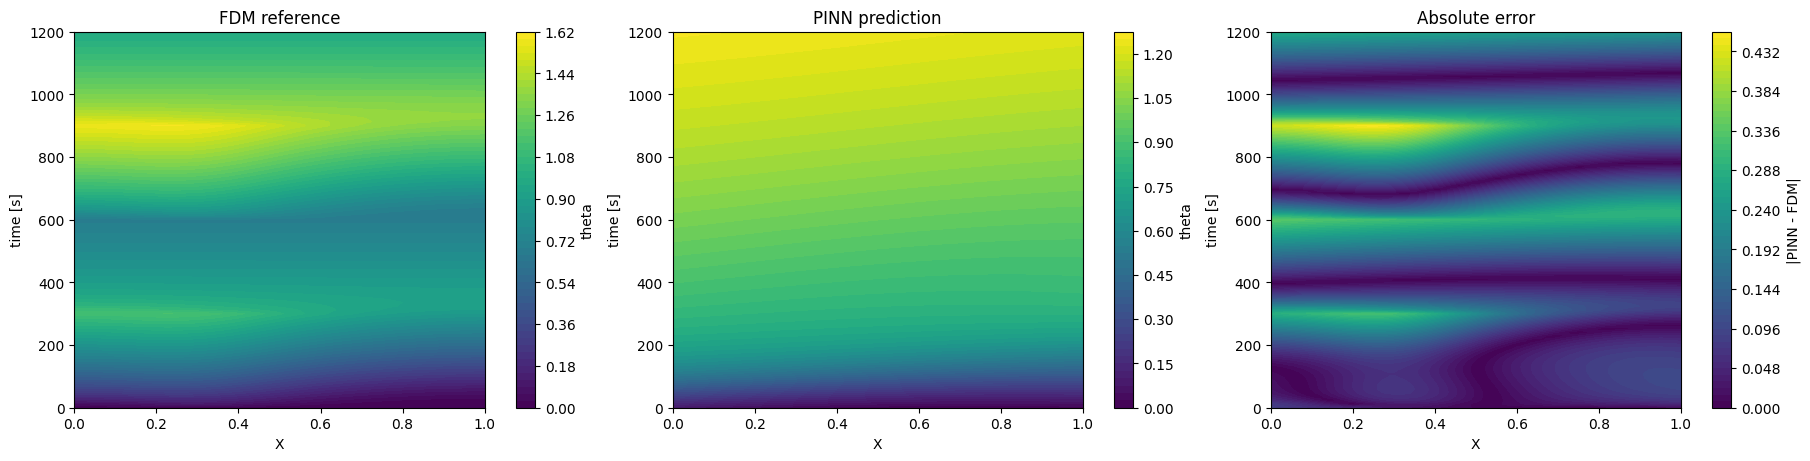

outputs/fdm_vs_pinn/fdm_pinn_full_field_contours.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), constrained_layout=True)

common_levels = 60

c0 = axes[0].contourf(x_values, time_seconds, theta_fdm, levels=common_levels)
axes[0].set_title("FDM reference")
axes[0].set_xlabel("X")
axes[0].set_ylabel("time [s]")
fig.colorbar(c0, ax=axes[0], label="theta")

c1 = axes[1].contourf(x_values, time_seconds, theta_pinn, levels=common_levels)
axes[1].set_title("PINN prediction")
axes[1].set_xlabel("X")
axes[1].set_ylabel("time [s]")
fig.colorbar(c1, ax=axes[1], label="theta")

c2 = axes[2].contourf(x_values, time_seconds, abs_error, levels=common_levels)
axes[2].set_title("Absolute error")
axes[2].set_xlabel("X")
axes[2].set_ylabel("time [s]")
fig.colorbar(c2, ax=axes[2], label="|PINN - FDM|")

fig_path = OUTPUT_DIR / "fdm_pinn_full_field_contours.png"
fig.savefig(fig_path, dpi=200)
plt.show()

print(fig_path)

## 7. Time Slice Comparison

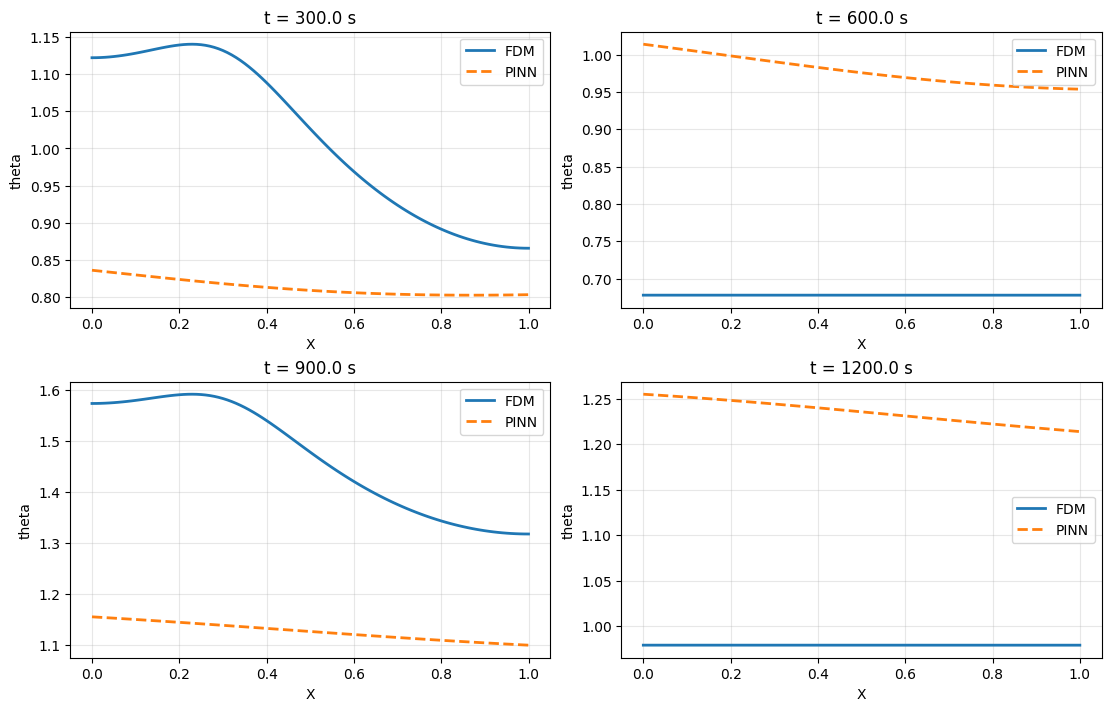

outputs/fdm_vs_pinn/fdm_pinn_time_slices.png


In [8]:
slice_times = [300.0, 600.0, 900.0, 1200.0]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
axes = axes.ravel()

for ax, target_time in zip(axes, slice_times):
    idx = int(np.argmin(np.abs(time_seconds - target_time)))
    ax.plot(x_values, theta_fdm[idx], label="FDM", linewidth=2)
    ax.plot(x_values, theta_pinn[idx], "--", label="PINN", linewidth=2)
    ax.set_title(f"t = {time_seconds[idx]:.1f} s")
    ax.set_xlabel("X")
    ax.set_ylabel("theta")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig_path = OUTPUT_DIR / "fdm_pinn_time_slices.png"
fig.savefig(fig_path, dpi=200)
plt.show()

print(fig_path)

## 8. Sensor Location Time Histories

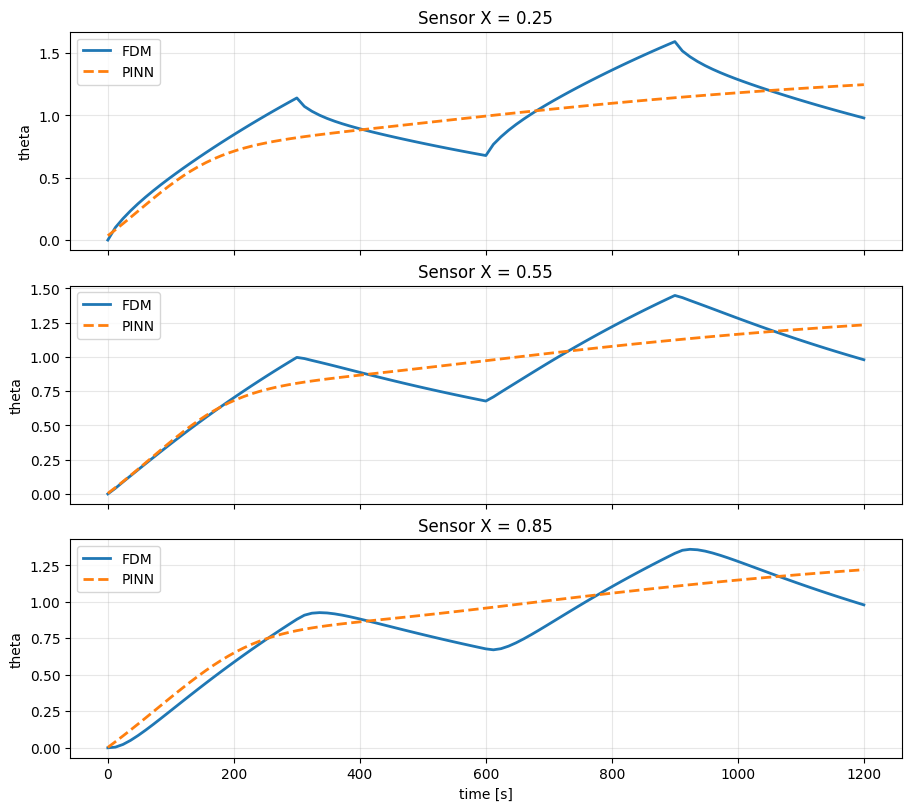

outputs/fdm_vs_pinn/fdm_pinn_sensor_histories.png


In [9]:
fig, axes = plt.subplots(len(m.SENSOR_X), 1, figsize=(9, 8), sharex=True, constrained_layout=True)

for ax, sensor_x in zip(axes, m.SENSOR_X):
    idx = int(round(sensor_x * (len(x_values) - 1)))
    ax.plot(time_seconds, theta_fdm[:, idx], label="FDM", linewidth=2)
    ax.plot(time_seconds, theta_pinn[:, idx], "--", label="PINN", linewidth=2)
    ax.set_ylabel("theta")
    ax.set_title(f"Sensor X = {sensor_x:.2f}")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("time [s]")

fig_path = OUTPUT_DIR / "fdm_pinn_sensor_histories.png"
fig.savefig(fig_path, dpi=200)
plt.show()

print(fig_path)

## 9. Summary for Report

In [10]:
print("FDM vs PINN full-field comparison")
print(f"iterations      : {ITERATIONS}")
print(f"network         : {args.depth} x {args.width}")
print(f"loss weights    : {m.LOSS_WEIGHTS}")
print(f"beta learned    : {beta_learned:.6f} / true {m.BETA_TRUE:.6f}")
print(f"S learned       : {s_learned:.6f} / true {m.S_TRUE:.6f}")
print(f"h learned       : {h_learned:.6f} / true {m.H_TRUE:.6f}")
print(f"q0 learned      : {q0_learned:.6e} / true {m.Q0_TRUE:.6e}")
print(f"MAE             : {mae:.6e}")
print(f"RMSE            : {rmse:.6e}")
print(f"Max error       : {max_error:.6e}")
print(f"Relative L2     : {rel_l2:.6e}")

FDM vs PINN full-field comparison
iterations      : 1000
network         : 3 x 32
loss weights    : [1.0, 10.0, 10.0, 10.0, 100.0]
beta learned    : 0.386593 / true 0.442193
S learned       : 1.089101 / true 5.389222
h learned       : 34.970551 / true 40.000000
q0 learned      : 1.616710e+04 / true 8.000000e+04
MAE             : 1.338234e-01
RMSE            : 1.651758e-01
Max error       : 4.501306e-01
Relative L2     : 1.688601e-01
